# 7 · Decoding in the projection

**What you will do:** classify the digit from the full 700-channel representation and from three reductions of it, then do the same *inside* two-, three- and ten-dimensional embeddings, and finally ask whether unsupervised clustering in those embeddings recovers the digits at all.

**What you should take away:** an embedding is a preprocessing step like any other, so it belongs inside the cross-validation fold — and the reason is not the one usually given. Fitting it on everything first does not reliably inflate your accuracy; on this data it lowers it. It makes the number incomparable, which is worse, because you cannot tell from the number alone which way the bias ran. And the groups a clustering algorithm finds are not obliged to be your classes.

Notebook 2 made five embeddings and measured their geometry. Notebook 3 decoded the original space. This one joins the two: it decodes *in* the embeddings, which is what people usually mean when they say a projection "separates the classes".

Runtime: five to eight minutes.

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from compbio2026 import data, decoding, filters, geometry, plotting

plotting.apply_style()
warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(2026)

BIN_MS = 25.0
N_TRIALS = 800
N_REDUCED = 100     # width of the pooled and selected representations

shd = data.load("train")
subset = rng.choice(np.flatnonzero(shd.english_mask()), size=N_TRIALS, replace=False)

X, y, t = data.build_design_matrix(shd, bin_ms=BIN_MS, t_max_ms=800.0,
                                   smooth_ms=10.0, trials=subset)
speaker = shd.speaker[subset]

print(f"X        {X.shape}   (trials, channels, bins)")
print(f"flat     {data.flatten(X).shape}")
print(f"rates    {data.rates(X, BIN_MS).shape}   one number per channel per trial")
print(f"{len(np.unique(y))} classes, chance {decoding.chance_level(y):.3f}; "
      f"{len(np.unique(speaker))} speakers")

X        (800, 700, 32)   (trials, channels, bins)
flat     (800, 22400)
rates    (800, 700)   one number per channel per trial
10 classes, chance 0.115; 10 speakers


## Part 1 · The original space and three reductions

Four representations of the same trials, all decoded with the same ridge readout and the same five-fold split.

- **Full space–time** — 700 channels × 32 bins. Everything the design matrix holds.
- **Rate vector** — the time axis averaged away, one number per channel. This is "the 700-dimensional dataset" in the sense that each trial is a point in a 700-dimensional space of channels, and it is the representation that discards spike timing entirely.
- **Pooled** — adjacent channels averaged into `N_REDUCED` tonotopic bands, keeping time.
- **Selected** — `N_REDUCED` whole channels kept, keeping time.

The last two are the operations from notebook 6, here at the same width so the comparison is about what each destroys rather than about how wide the matrix is.

**One thing has to be got right before any of this means anything.** These representations differ in width by a factor of 200, and the right ridge penalty is not the same for 700 correlated channels as for 22 400 space–time features. Comparing them at one fixed `alpha` measures the penalty as much as the representation. Every row below therefore uses `RidgeClassifierCV`, which picks its own `alpha` by efficient leave-one-out inside the training fold. The last column shows what the fixed-`alpha` version would have said, and for one row the difference is enormous.

In [2]:
rates = data.rates(X, BIN_MS)
X_pooled = filters.pool_channels(X, N_REDUCED)
X_selected, kept = filters.select_channels(X, N_REDUCED, method="uniform")

from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ALPHAS = np.logspace(-1, 5, 13)
cv = StratifiedKFold(5, shuffle=True, random_state=0)


def tuned():
    """Ridge whose penalty is chosen inside the training fold."""
    return make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=ALPHAS))


representations = {
    "full space-time (700 x 32)": data.flatten(X),
    "rate vector (700)": rates,
    f"pooled to {N_REDUCED} bands x 32": data.flatten(X_pooled),
    f"{N_REDUCED} selected channels x 32": data.flatten(X_selected),
    f"pooled rate vector ({N_REDUCED})": data.rates(X_pooled, BIN_MS),
}

rows = []
for name, F in representations.items():
    s = cross_val_score(tuned(), F, y, cv=cv)
    fixed = cross_val_score(make_pipeline(StandardScaler(), RidgeClassifier(alpha=1.0)),
                            F, y, cv=cv)
    rows.append({"representation": name, "features": F.shape[1],
                 "accuracy": s.mean(), "sd": s.std(), "at fixed alpha=1": fixed.mean()})
rows.append({"representation": "chance", "features": 0,
             "accuracy": decoding.chance_level(y), "sd": 0.0,
             "at fixed alpha=1": decoding.chance_level(y)})
space_table = pd.DataFrame(rows).set_index("representation")
space_table.round(3)

,features,accuracy,sd,at fixed alpha=1
representation,,,,
full space-time (700 x 32),22400,0.840,0.029,0.840
rate vector (700),700,0.659,0.025,0.221
pooled to 100 bands x 32,3200,0.858,0.035,0.806
100 selected channels x 32,3200,0.765,0.030,0.722
pooled rate vector (100),100,0.709,0.019,0.678
chance,0,0.115,0.000,0.115


Two things in that table.

**The rate vector row is a warning about hyperparameters, not about rate codes.** At a fixed `alpha` of 1 it scores 0.221 — far below the 100-band pooled version of itself, which contains strictly less information. Nothing is wrong with the data. Pooling seven neighbouring channels averages away noise that the penalty would otherwise have to absorb, and at `alpha = 1` the penalty cannot absorb it. Tune `alpha` and the row roughly triples, landing where the pooled version sits. A representation that looks worse may simply be one whose hyperparameter you did not tune, and a table of accuracies at a single fixed setting is a table about that setting.

**Pooling to 100 bands beats the unpooled matrix**, 0.858 against 0.840, with a seventh of the features. Averaging neighbouring channels is denoising here rather than discarding, which is what a redundant code predicts and what notebook 6 measured at a different width. Note that the ranking of pooling against selection is unchanged by the tuning; only the rate vector moved.

## Averaging per digit

The next thing to compare is what happens when you average trials *within* a digit. Ten class means, one per word, and a trial is labelled by whichever mean it is closest to. That is a real classifier — `NearestCentroid` — and the simplest possible use of a class average.

It is also somewhere you can quietly produce a number that is not a result. The class means have to be computed from the training fold only; compute them from all the data and every test trial has already contributed to the mean it is being compared against.

In [3]:
from sklearn.neighbors import NearestCentroid

honest = cross_val_score(make_pipeline(StandardScaler(), NearestCentroid()), rates, y, cv=cv)

# The same classifier, but the class means are computed once on everything first.
scaler = StandardScaler().fit(rates)
Z = scaler.transform(rates)
centroids = np.stack([Z[y == c].mean(axis=0) for c in np.unique(y)])
leaked_pred = np.argmin(((Z[:, None, :] - centroids[None]) ** 2).sum(-1), axis=1)
leaked = (np.unique(y)[leaked_pred] == y).mean()

print(f"nearest class mean, fitted inside the fold   {honest.mean():.3f} +/- {honest.std():.3f}")
print(f"the same thing with the means fitted on all  {leaked:.3f}   <- not a result")
print(f"chance                                       {decoding.chance_level(y):.3f}")

nearest class mean, fitted inside the fold   0.570 +/- 0.043
the same thing with the means fitted on all  0.606   <- not a result
chance                                       0.115


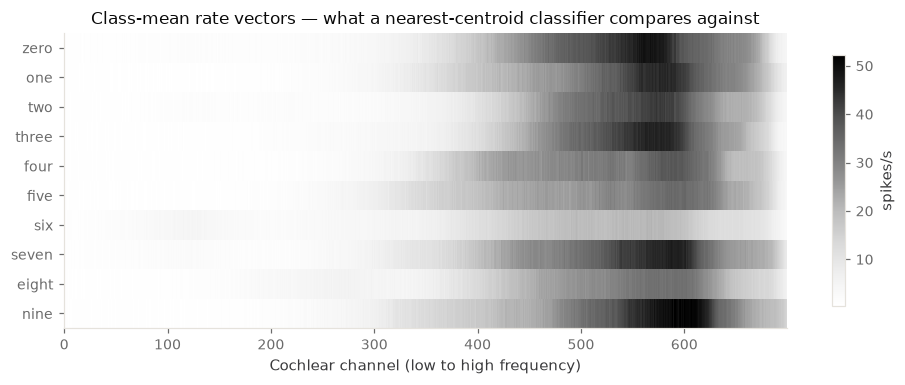

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.6))
means = np.stack([rates[y == c].mean(axis=0) for c in range(10)])
im = ax.imshow(means, aspect="auto", cmap="Greys", interpolation="nearest")
ax.set_yticks(range(10))
ax.set_yticklabels(data.DIGIT_KEYS[:10])
ax.set_xlabel("Cochlear channel (low to high frequency)")
ax.set_title("Class-mean rate vectors — what a nearest-centroid classifier compares against")
fig.colorbar(im, ax=ax, shrink=0.85, label="spikes/s")
fig.tight_layout()
plotting.savefig(fig, "07_class_means", outdir="../plots")

## Part 2 · Decoding inside the projection

Now the question this notebook exists for. Notebook 2 projected the data into two dimensions and looked at the picture. What happens if a classifier is trained *in* that two-dimensional space?

The answer depends entirely on **when the projection is fitted**, and this is the single most common mistake in the literature this project draws on. A projection is a model with parameters. Fit it on all your trials, then cross-validate a classifier on the result, and the test trials helped choose the axes they are then scored in. The fix is mechanical: put the reducer in the pipeline, so every fold fits its own.

```python
make_pipeline(StandardScaler(), PCA(50), reducer, StandardScaler(), RidgeClassifier())
```

Every method below is fitted this way, on the training fold only, with a 50-component PCA in front to keep the nonlinear methods tractable — the same front-end notebook 2 used. **t-SNE is the exception**: it has no `transform` method, cannot embed a held-out point at all, and therefore cannot appear in a pipeline. That is a property of the algorithm, not an oversight.

In [5]:
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
import umap

def projected(reducer):
    """Reducer fitted inside the fold, then a linear readout in its output space."""
    return make_pipeline(StandardScaler(), PCA(n_components=50, random_state=0),
                         reducer, StandardScaler(), RidgeClassifierCV(alphas=ALPHAS))

Xf = data.flatten(X)
methods = []
for n in [2, 3, 10, 50]:
    methods.append(("PCA", n, PCA(n_components=n, random_state=0)))
for n in [2, 3, 10]:
    methods.append(("Isomap", n, Isomap(n_components=n, n_neighbors=15)))
    methods.append(("UMAP", n, umap.UMAP(n_components=n, n_neighbors=15, random_state=0)))

rows = []
for name, n, reducer in methods:
    s = cross_val_score(projected(reducer), Xf, y, cv=cv)
    rows.append({"method": name, "components": n, "accuracy": s.mean(), "sd": s.std()})
    print(f"  {name:7s} {n:2d}D  {s.mean():.3f}")

proj_table = pd.DataFrame(rows)
proj_table.pivot(index="components", columns="method", values="accuracy").round(3)

  PCA      2D  0.241


  PCA      3D  0.310


  PCA     10D  0.532


  PCA     50D  0.723


  Isomap   2D  0.223


...

  Isomap   3D  0.353


  UMAP     3D  0.469


  Isomap  10D  0.509


  UMAP    10D  0.630


method,Isomap,PCA,UMAP
components,,,
2,0.222,0.241,0.358
3,0.353,0.310,0.469
10,0.509,0.532,0.630
50,NaN,0.723,NaN


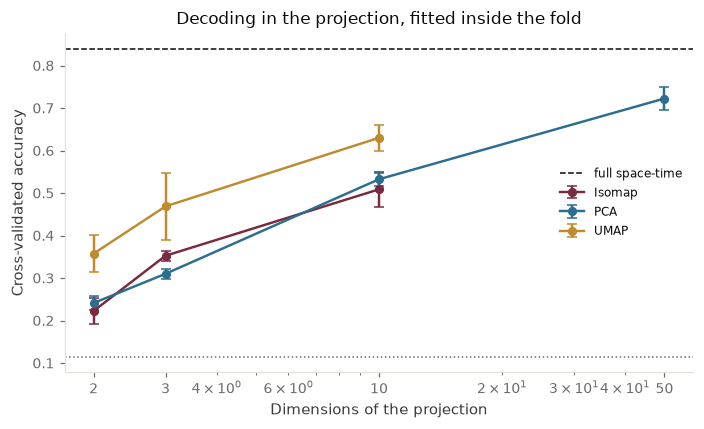

In [6]:
full = space_table.loc["full space-time (700 x 32)", "accuracy"]

fig, ax = plt.subplots(figsize=(6.5, 4))
for name, grp in proj_table.groupby("method"):
    ax.errorbar(grp["components"], grp["accuracy"], yerr=grp["sd"],
                marker="o", ms=5, capsize=3, label=name)
ax.axhline(full, ls="--", lw=1, color=plotting.INK, label="full space-time")
ax.axhline(decoding.chance_level(y), ls=":", lw=1, color=plotting.INK_MUTED)
ax.set_xscale("log")
ax.set_xticks([2, 3, 10, 50])
ax.set_xticklabels([2, 3, 10, 50])
ax.set_xlabel("Dimensions of the projection")
ax.set_ylabel("Cross-validated accuracy")
ax.set_title("Decoding in the projection, fitted inside the fold")
ax.legend(fontsize=8)
fig.tight_layout()
plotting.savefig(fig, "07_projection_decoding", outdir="../plots")

## The leak, measured — and it does not go the way the warning implies

Same embedding, same classifier, same folds. The only difference is whether the embedding saw the test trials while it was being fitted.

In [7]:
from sklearn.manifold import TSNE

Z50 = PCA(n_components=50, random_state=0).fit_transform(StandardScaler().fit_transform(Xf))

leaky = {}
for name, reducer in [("UMAP 2D", umap.UMAP(n_components=2, n_neighbors=15, random_state=0)),
                      ("Isomap 2D", Isomap(n_components=2, n_neighbors=15)),
                      ("t-SNE 2D", TSNE(n_components=2, perplexity=30, init="pca", random_state=0))]:
    Z = reducer.fit_transform(Z50)                       # fitted on every trial, labels included
    s = cross_val_score(make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=ALPHAS)),
                        Z, y, cv=cv)
    leaky[name] = s.mean()

honest_2d = proj_table.set_index(["method", "components"])["accuracy"]
comparison = pd.DataFrame({
    "fitted inside the fold": [honest_2d[("UMAP", 2)], honest_2d[("Isomap", 2)], np.nan],
    "fitted on everything": [leaky["UMAP 2D"], leaky["Isomap 2D"], leaky["t-SNE 2D"]],
}, index=["UMAP 2D", "Isomap 2D", "t-SNE 2D"])
comparison.round(3)

,fitted inside the fold,fitted on everything
UMAP 2D,0.358,0.249
Isomap 2D,0.222,0.216
t-SNE 2D,NaN,0.219


**Read the two columns before drawing the usual moral.** Fitting the embedding on everything did *not* inflate the accuracy here — for UMAP it lowered it, and for Isomap the two agree within noise.

That is not an accident, and it is worth understanding rather than filing away. UMAP and Isomap never see the labels. Fitting them on all the trials leaks the shape of the *unlabelled* data, which is transduction rather than label leakage, and transduction is not automatically an advantage: one embedding fitted to 800 points is not obliged to be more linearly separable than five embeddings each fitted to 640 and evaluated on their own held-out points. The nearest-centroid comparison earlier is the case where a genuine label leak shows up, and even there it was modest.

So keep the rule — fit the reducer inside the fold — but keep it for the right reason. Not because unsupervised embeddings flatter you, but because **you cannot tell in advance which way the bias runs**, and a number computed the second way is not comparable to one computed the first. Where the inflation does become large is when the reducer uses the labels; exercise 3 puts `LinearDiscriminantAnalysis` in the same harness and the difference there is not subtle.

The t-SNE row has no honest entry because there is no honest version: the algorithm cannot place a new point at all. Any t-SNE-based classification accuracy you have seen was computed the second way.

## Part 3 · What clustering finds

Decoding asks whether the classes are *recoverable* by something that has been told what they are. Clustering asks a different question: does the structure fall apart into groups on its own, and do those groups correspond to the digits?

Four algorithms with different assumptions — spherical clusters of equal size, full-covariance Gaussians, a hierarchy of merges, and density with no preset number of clusters — on each of three 10-dimensional projections. Scored two ways, because a clustering can be excellent and about the wrong thing.

- **Adjusted Rand index** against the digit label, and against the **speaker**. SHD has twelve speakers, and voice is the most obvious competing source of structure in the data.
- **Number of clusters found**, which is the interesting output for DBSCAN and is fixed at ten for the others.

Two implementation notes that are not incidental. The mixture uses a **diagonal** covariance: UMAP output has near-collapsed directions and a full covariance is singular there, which is a fact about the embedding rather than about the data. And DBSCAN's `eps` is set from the data — 1.5 times the median distance to the tenth nearest neighbour — rather than typed in, because a hand-picked `eps` makes a density result unfalsifiable.

In [8]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.mixture import GaussianMixture

from sklearn.neighbors import NearestNeighbors

# Standardised, because DBSCAN's eps and the mixture's covariance are both
# scale-dependent and the three spaces have wildly different scales.
spaces = {
    "PCA 10D": PCA(n_components=10, random_state=0).fit_transform(Z50),
    "Isomap 10D": Isomap(n_components=10, n_neighbors=15).fit_transform(Z50),
    "UMAP 10D": umap.UMAP(n_components=10, n_neighbors=15, random_state=0).fit_transform(Z50),
}
spaces = {k: StandardScaler().fit_transform(Z) for k, Z in spaces.items()}


def dbscan_auto(Z, k=10):
    """DBSCAN with eps set from the data: 1.5x the median distance to the kth neighbour."""
    d, _ = NearestNeighbors(n_neighbors=k).fit(Z).kneighbors(Z)
    return DBSCAN(eps=1.5 * float(np.median(d[:, -1])), min_samples=k).fit_predict(Z)


algorithms = {
    "KMeans": lambda Z: KMeans(n_clusters=10, n_init=10, random_state=0).fit_predict(Z),
    # Diagonal covariance: UMAP output has near-collapsed directions, and a full
    # covariance is singular there.
    "Gaussian mixture": lambda Z: GaussianMixture(n_components=10, covariance_type="diag",
                                                  reg_covar=1e-3, random_state=0).fit_predict(Z),
    "Agglomerative": lambda Z: AgglomerativeClustering(n_clusters=10).fit_predict(Z),
    "DBSCAN": dbscan_auto,
}

rows = []
for space, Z in spaces.items():
    for algo, fn in algorithms.items():
        lab = fn(Z)
        rows.append({"space": space, "algorithm": algo,
                     "clusters": len(set(lab) - {-1}),
                     "unassigned": int((lab == -1).sum()),
                     "ARI vs digit": adjusted_rand_score(y, lab),
                     "NMI vs digit": normalized_mutual_info_score(y, lab),
                     "ARI vs speaker": adjusted_rand_score(speaker, lab)})
cluster_table = pd.DataFrame(rows).set_index(["space", "algorithm"])
cluster_table.round(3)

clusters  unassigned  ARI vs digit  NMI vs digit  \
space      algorithm                                                            
PCA 10D    KMeans                  10           0         0.218         0.370   
           Gaussian mixture        10           0         0.227         0.382   
           Agglomerative           10           0         0.211         0.380   
           DBSCAN                   1          43         0.003         0.047   
Isomap 10D KMeans                  10           0         0.212         0.379   
           Gaussian mixture        10           0         0.210         0.390   
           Agglomerative           10           0         0.213         0.384   
           DBSCAN                   2          77         0.008         0.073   
UMAP 10D   KMeans                  10           0         0.271         0.443   
           Gaussian mixture        10           0         0.281         0.446   
           Agglomerative           10           0         0.274         0.445   
           DBSCAN                  20          33         0.220         0.474   

                             ARI vs speaker  
space      algorithm                         
PCA 10D    KMeans                     0.156  
           Gaussian mixture           0.157  
           Agglomerative              0.117  
           DBSCAN                     0.001  
Isomap 10D KMeans                     0.149  
           Gaussian mixture           0.147  
           Agglomerative              0.184  
           DBSCAN                     0.008  
UMAP 10D   KMeans                     0.182  
           Gaussian mixture           0.214  
           Agglomerative              0.183  
           DBSCAN                     0.200

KMeans on the 2D UMAP:  ARI vs digit 0.292, ARI vs speaker 0.205


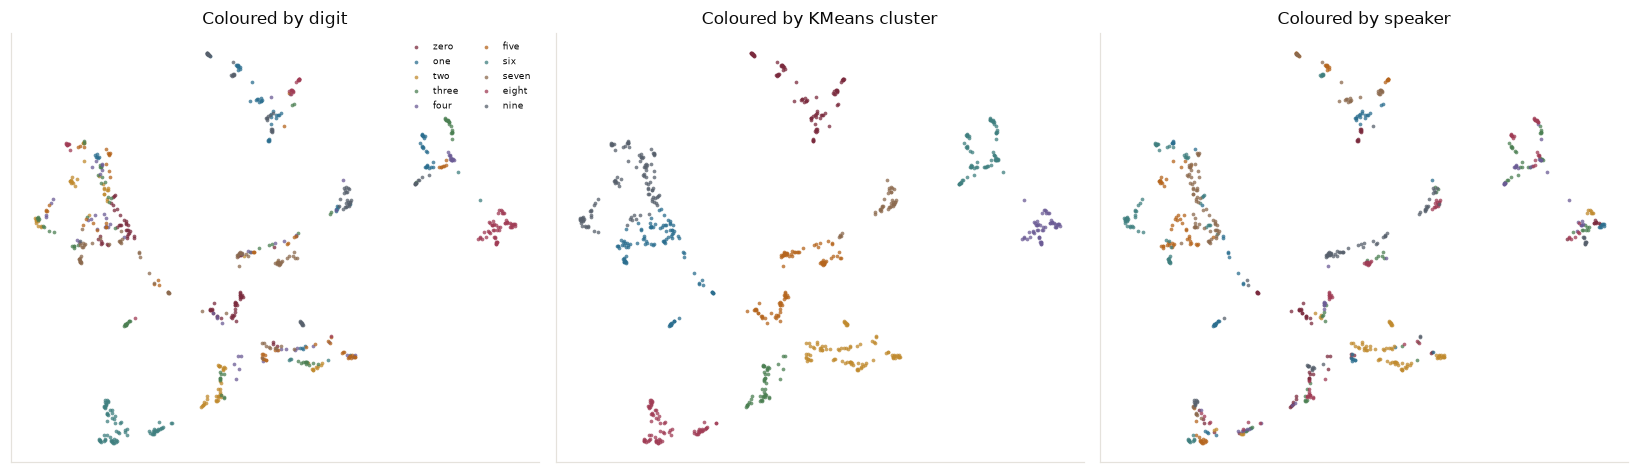

In [9]:
Z2 = umap.UMAP(n_components=2, n_neighbors=15, random_state=0).fit_transform(Z50)
km2 = KMeans(n_clusters=10, n_init=10, random_state=0).fit_predict(Z2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (title, colour, labels) in zip(axes, [
        ("Coloured by digit", y, data.DIGIT_KEYS[:10]),
        ("Coloured by KMeans cluster", km2, None),
        ("Coloured by speaker", speaker, None)]):
    plotting.embedding(Z2, colour, labels=labels, ax=ax, s=6)
    ax.set_title(title)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticks([]); ax.set_yticks([])
    if labels is None and ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0].legend(ncol=2, fontsize=6)
fig.tight_layout()
plotting.savefig(fig, "07_clustering", outdir="../plots")

print(f"KMeans on the 2D UMAP:  ARI vs digit {adjusted_rand_score(y, km2):.3f}, "
      f"ARI vs speaker {adjusted_rand_score(speaker, km2):.3f}")

---

## Reading all three parts together

Write down the four numbers that matter: the full space–time accuracy, the best accuracy inside a projection fitted honestly, the same projection fitted on everything, and the best clustering agreement with the digit labels. They answer different questions and are routinely reported as if they answered the same one.

Every projection here loses to the full space–time representation, and by a lot at two and three dimensions — which is the arithmetic behind notebook 2's warning about judging an embedding by its picture. UMAP is consistently the best of the three at matched width, and consistently far below what the unprojected data supports.

A projection that decodes well has kept the class information. A projection that clusters well has found *some* partition, and whether it is the partition you care about is what the speaker column is for: on the two-dimensional UMAP the clusters agree with the digit only slightly more than with the voice.

## What is wrong with this notebook

- **The reducers were not tuned.** `n_neighbors = 15` throughout, one value, no sweep. Notebook 2's exercise 2 is the relevant one, and the ranking here may not survive it.
- **`DBSCAN`'s `eps` comes from one heuristic** — the median tenth-neighbour distance, scaled by a constant that was itself typed in. Better than a bare number, still a free parameter. Report the sweep, not the point.
- **Speaker and digit are not independent** in this subset: with 800 trials drawn at random, some speaker–digit combinations are rare, so the two ARI columns are not fully separable.
- **800 trials, ten classes.** Cross-validated accuracies have a standard error of a couple of percent.
- **PCA-50 in front of everything** is itself a choice, and a linear one. It bounds what the nonlinear methods can find.

## Exercises

1. **Sweep the neighbourhood.** Repeat Part 2 with `n_neighbors` in {5, 15, 50}. Does UMAP still beat PCA at the same dimensionality, and does the gap survive?
2. **Hold out speakers instead of trials.** Pass `groups=shd.speaker[subset]` to `decoding.decode` for the representations in Part 1, and re-run the honest projection pipeline with `GroupKFold`. How much of the accuracy was voice?
3. **Supervised projections.** Add `LinearDiscriminantAnalysis` as a reducer. It uses the labels, so it must be inside the fold; how much better is it than PCA at the same width, and is that a fair comparison?
4. **Cluster count.** For KMeans, sweep `n_clusters` from 2 to 20 and plot ARI against the digit labels. Does the peak sit at ten?
5. **Cluster the original space.** Run the same four algorithms on the rate vectors directly, with no projection. Does the embedding help the clustering, or only the picture?
6. **The honest t-SNE.** There is no `transform`, but you can re-fit t-SNE on train-plus-test with the test labels hidden. Argue whether that counts as leakage, and design a test that settles it.

Next: **[8 · Driving a biophysical layer](08_jaxley_hh_layer.ipynb)** — the same spikes, into Hodgkin–Huxley neurons.